# E-Commerce Sales Prediction model

This business is working towards optimizing inventory and supply chain decisions by identifying time of high demand. However, there is
no structured system that can forecast sales trend across time. This creates problems in restocking, leading stockout during peak demands.
This project aims at analyzing the sales data to identify patterns and trends, and then build a predictive model to forecast future sales. 
The insights gained from this analysis will help the business make informed decisions about inventory management, marketing strategies and overall business planning.

In [137]:
# Import the necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score



Data Loading and Cleaning

In [138]:
# Load the dataset
df=pd.read_csv(r'C:\Users\USER\OneDrive\Desktop\Ecommerce_Sales_Data_2024_2025.csv')
df.info()
df.describe()
# Check for missing values
print("\nMissing values in each column:")
print(df.isnull().sum())
# Check for duplicates
print("\nNumber of duplicate rows:", df.duplicated().sum())

# Detecting Outliers using IQR
print("\nShape before outlier removal:", df.shape)
numerical_cols = ['Sales', 'Quantity', 'Discount', 'Profit']
for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[col] < lower_bound) | (df[col] > upper_bound)]
    print(f"\nOutliers in {col}:")
    print(f"\n{outliers[[col]]}")
print("\nShape after outlier removal:", df.shape)




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 14 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Order ID       5000 non-null   int64  
 1   Order Date     5000 non-null   object 
 2   Customer Name  5000 non-null   object 
 3   Region         5000 non-null   object 
 4   City           5000 non-null   object 
 5   Category       5000 non-null   object 
 6   Sub-Category   5000 non-null   object 
 7   Product Name   5000 non-null   object 
 8   Quantity       5000 non-null   int64  
 9   Unit Price     5000 non-null   int64  
 10  Discount       5000 non-null   int64  
 11  Sales          5000 non-null   float64
 12  Profit         5000 non-null   float64
 13  Payment Mode   5000 non-null   object 
dtypes: float64(2), int64(4), object(8)
memory usage: 547.0+ KB

Missing values in each column:
Order ID         0
Order Date       0
Customer Name    0
Region           0
City             

The dataset of 5000 rows and 14 columns was checked for missing values and duplicates and no issues were found.Outliers in the numerical columns were detected using the IQR method, 
the shape of the dataset before and after outlier removal was printed.Since the shape is the same , it indicates that no outliers were removed from the dataset. 
This suggests that the dataset is clean and ready for further analysis and modeling without any outlier-related issues.

# Feature Engineering

In [136]:
# Date Handling
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Year'] = df['Order Date'].dt.year
df['Month'] = df['Order Date'].dt.month 
df['Day'] = df['Order Date'].dt.day
df.shape

(5000, 17)

From the  Order Date variable, we obtained the year, month and day features. This explains the increase
of columns from 14 to 17

# Exploratory Data Analysis
Here, we will perform multivariate analysis, skewness, kurtosis, and correlation analysis.
Additionally, we will check the trend of sales over time and their distribution over different categories and regions

# Correlation analysis

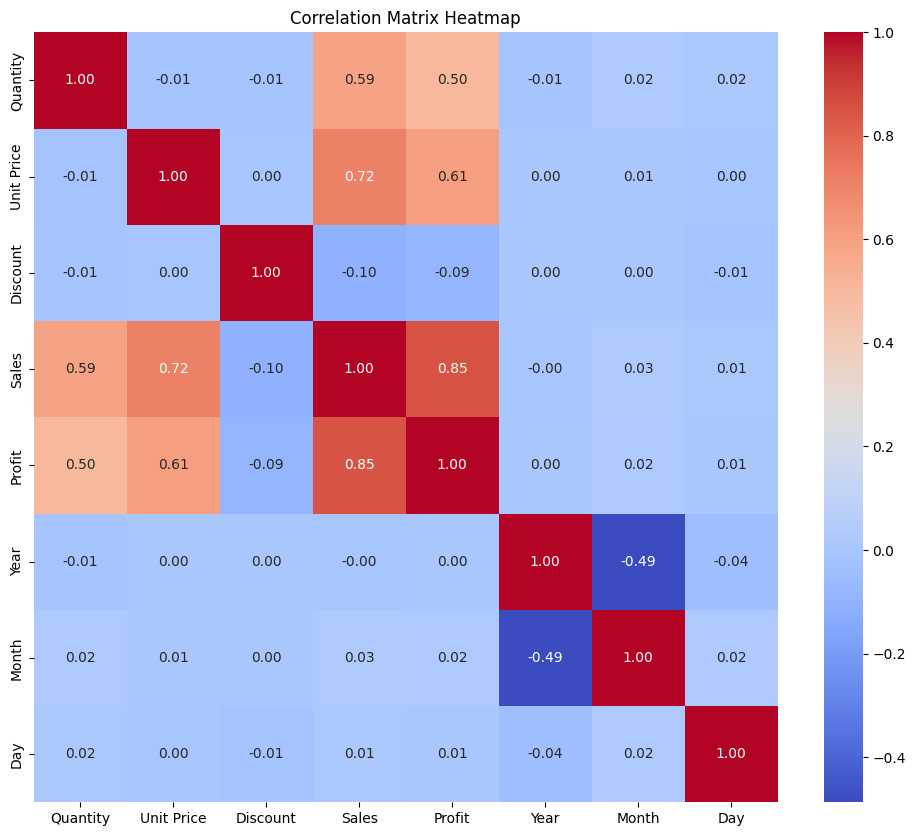

            Quantity  Unit Price  Discount     Sales    Profit      Year  \
Quantity    1.000000   -0.010982 -0.007955  0.588705  0.502701 -0.009208   
Unit Price -0.010982    1.000000  0.000475  0.715123  0.606293  0.003286   
Discount   -0.007955    0.000475  1.000000 -0.101611 -0.088516  0.002388   
Sales       0.588705    0.715123 -0.101611  1.000000  0.848792 -0.003165   
Profit      0.502701    0.606293 -0.088516  0.848792  1.000000  0.003157   
Year       -0.009208    0.003286  0.002388 -0.003165  0.003157  1.000000   
Month       0.020833    0.010850  0.001170  0.026437  0.023636 -0.487371   
Day         0.015853    0.000161 -0.012187  0.014422  0.012217 -0.041253   

               Month       Day  
Quantity    0.020833  0.015853  
Unit Price  0.010850  0.000161  
Discount    0.001170 -0.012187  
Sales       0.026437  0.014422  
Profit      0.023636  0.012217  
Year       -0.487371 -0.041253  
Month       1.000000  0.018792  
Day         0.018792  1.000000  


In [109]:
#Correlation analysis between the numeric features and sales
numeric_cols = [col for col in df.select_dtypes(include=['number']).columns if col not in ['Order ID', 'Order Id']  ]
correlation_matrix = df[numeric_cols].corr()
# Visualize the correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap')
plt.show()

# Print the correlation values
print(correlation_matrix)


We can see that there is a strong positive relationship between sales and profit and a moderate
relationship between sales and quantity. Additionally , there is a weak negative correlation between
sales and order Id.

Now let's encode the non numerical fatures and check the overall correlation again

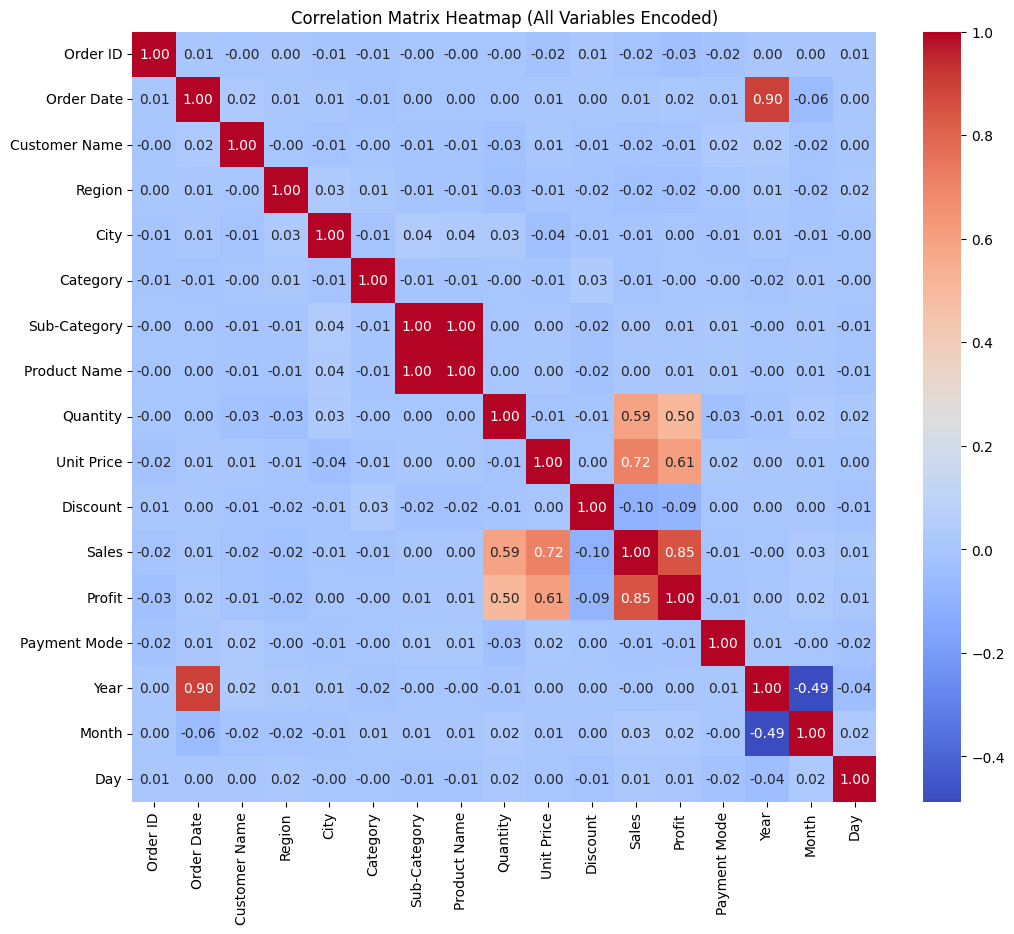

               Order ID  Order Date  Customer Name    Region      City  \
Order ID       1.000000    0.007415      -0.001163  0.001479 -0.007729   
Order Date     0.007415    1.000000       0.020196  0.008766  0.005477   
Customer Name -0.001163    0.020196       1.000000 -0.004403 -0.012064   
Region         0.001479    0.008766      -0.004403  1.000000  0.029455   
City          -0.007729    0.005477      -0.012064  0.029455  1.000000   
Category      -0.008964   -0.012992      -0.003408  0.012654 -0.014535   
Sub-Category  -0.003487    0.000337      -0.010851 -0.007709  0.035625   
Product Name  -0.003929    0.000625      -0.010788 -0.007409  0.035443   
Quantity      -0.002673    0.000522      -0.025415 -0.031912  0.025399   
Unit Price    -0.017612    0.009190       0.005909 -0.008209 -0.036581   
Discount       0.010596    0.002794      -0.009606 -0.016536 -0.005984   
Sales         -0.016595    0.010204      -0.015393 -0.023188 -0.006425   
Profit        -0.028416    0.015938   

In [110]:
# Encoding the non numerical features (Label Encoding)
df_encoded = df.copy()
label_encoder = LabelEncoder()  
for column in df_encoded.select_dtypes(include=['object']).columns:
    df_encoded[column] = label_encoder.fit_transform(df_encoded[column])

# Calculate the correlation matrix for the encoded dataframe
correlation_matrix_encoded = df_encoded.corr()

# Visualize the new correlation matrix using a heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(correlation_matrix_encoded, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix Heatmap (All Variables Encoded)')
plt.show()

# Print the correlation values
print(correlation_matrix_encoded)


# Insights
From the correlation analysis, we can see that sales has a strong relationship with profit. That implies that to increase profit, 
The busines needs to focus on maximizing the sales. Moreover, Sales are highly dependent on the quantity sold and the unit price.
Therefore predicting the sales trend to restock the inventory will lead to an increase of the quantity of goods sold during peak demands hence
an increased profit leading to the business success.

# Multivariate Analysis

In [111]:
# Multivariate analysis
display (df.groupby(['Category', 'Region'])['Sales'].sum().sort_values(ascending=False))

Category     Region
Kitchen      West      17323216.35
Home Decor   North     17286752.95
Furniture    West      16895925.05
Clothing     North     15930578.90
Home Decor   East      15589662.00
Books        North     15441895.30
Electronics  East      15165897.55
Furniture    North     15085776.75
Electronics  North     14439593.55
Groceries    North     14357007.65
Books        East      14173354.80
Beauty       North     13984910.85
Sports       North     13754083.95
Clothing     East      13684994.15
Toys         East      13539714.50
Kitchen      South     13399212.00
Clothing     South     13261557.80
Toys         South     13168919.85
Furniture    East      13090179.45
Toys         West      13002164.05
Sports       East      12964689.30
Books        South     12948754.30
Beauty       East      12790403.80
Kitchen      East      12724395.80
Sports       South     12687812.90
             West      12662811.10
Toys         North     12516568.05
Books        West      12368638.60


In [112]:
display (df.groupby(['Category', 'City'])['Sales'].sum().sort_values(ascending=False))

Category    City              
Kitchen     Goa                   5014747.95
Books       Lucknow               4695507.05
Clothing    Bangalore             4329827.95
Beauty      Guwahati              4271225.30
Kitchen     Chennai               4212727.05
                                     ...    
Clothing    Ahmedabad             1538676.75
Furniture   Thiruvananthapuram    1534306.00
Home Decor  Surat                 1485377.55
Beauty      Thiruvananthapuram    1297776.65
Home Decor  Hyderabad             1209691.75
Name: Sales, Length: 200, dtype: float64

In [113]:
display (df.groupby(['Payment Mode', 'Region'])['Sales'].sum().sort_values(ascending=False))

Payment Mode  Region
COD           North     31875487.85
Credit Card   East      30595538.50
Net Banking   North     29814580.20
Debit Card    East      28891423.00
Credit Card   North     28538077.10
Net Banking   West      28519375.65
Debit Card    North     28286333.20
COD           West      28083905.20
Net Banking   East      27663018.60
UPI           South     26303804.05
COD           South     25468819.90
Net Banking   South     25468541.60
UPI           West      25369539.15
              East      25208474.55
              North     25063767.75
Debit Card    West      24783681.15
Credit Card   West      24289472.20
COD           East      23453183.30
Debit Card    South     23384944.30
Credit Card   South     22604057.10
Name: Sales, dtype: float64

In [114]:
display (df.groupby(['Month', 'Region', 'City', 'Category'])['Sales'].sum().sort_values(ascending=False))

Month  Region  City         Category   
6      East    Guwahati     Beauty         1167400.50
11     West    Goa          Kitchen        1064592.60
1      South   Hyderabad    Beauty         1036740.40
6      North   Chandigarh   Furniture      1032683.15
       West    Pune         Clothing       1022298.35
                                              ...    
10     North   Lucknow      Toys              1242.70
9      East    Bhubaneswar  Toys              1105.85
3      West    Pune         Electronics       1041.25
2      East    Ranchi       Groceries          912.00
1      South   Coimbatore   Kitchen            374.40
Name: Sales, Length: 2092, dtype: float64

From the analysis we discovered that during the month of June, in the East region, we had the highest sales 
in goods from beauty category. The specific city is Guwahati. This show that the demand of beauty products in Guwahati in June were high.
If the business had made more restocking and marketing efforts then they would probably have made more sales and profit.
Let us proceed to check the sales relationship with other variables using pairplot and scatter plot.

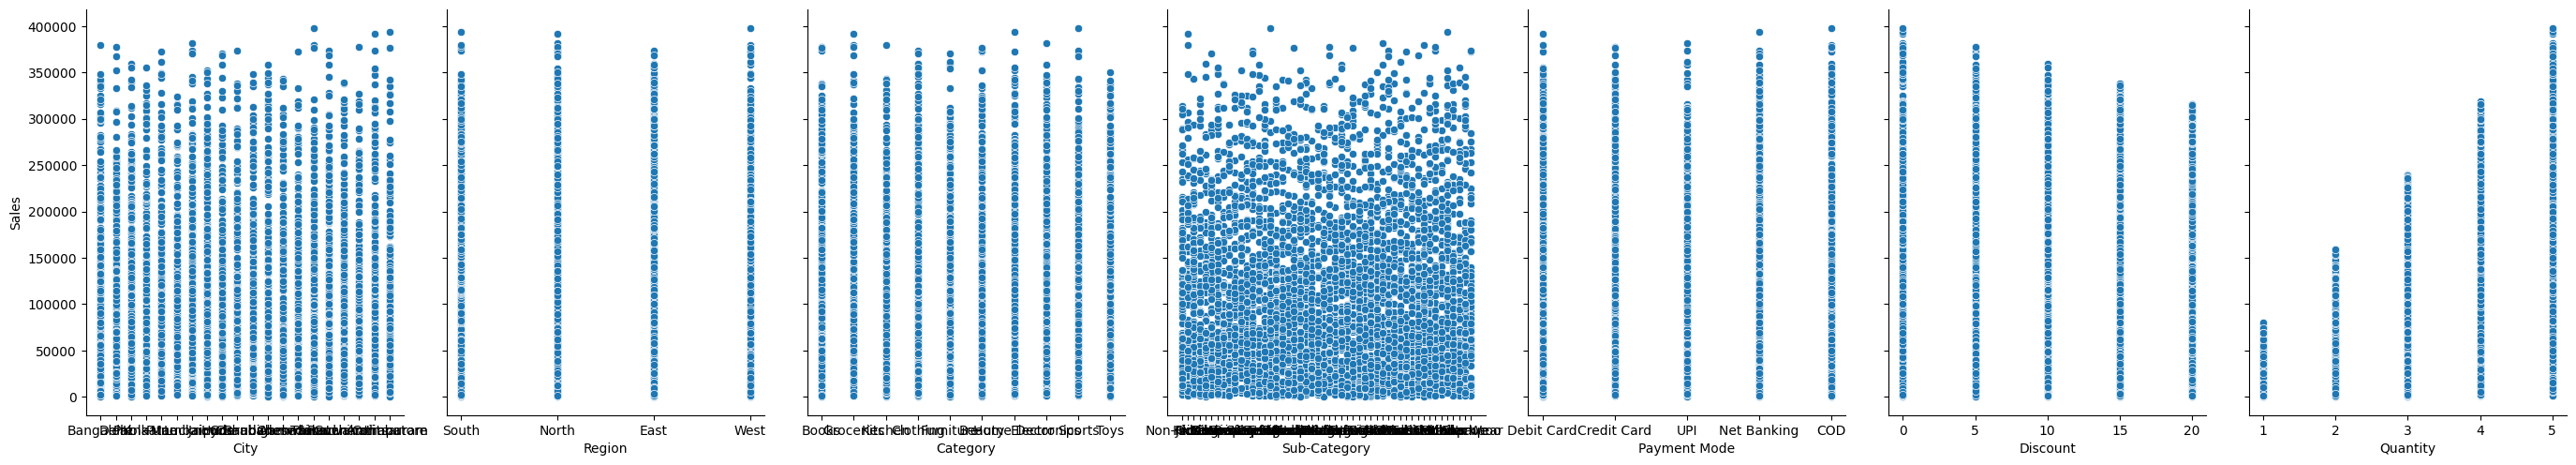

In [115]:
# Check linearity between sales and city, Region, Category, Sub-Category, Payment Mode
sns.pairplot(df, x_vars=['City', 'Region', 'Category', 'Sub-Category', 'Payment Mode', 'Discount', 'Quantity'], y_vars='Sales', height=5, aspect=0.8)
plt.show()

As we can see , Sales has a linear relationship with all these features . That is : 
City
Region
Category
Sub-Category
Payment Mode 
Now we can proceed to build a regression model to predict sales based on these features. 
Since Sales and Profit have a strong positive correlation, It will be easier to identify the 
Profit when we have the sales value. Additionally, an increase in sales will lkely lead
to an increase in profit

# Checking skewness and kurtosis


In [116]:
df['Quantity'].skew()



np.float64(-0.006054874121027674)

In [117]:
df['Unit Price'].skew()

np.float64(0.023700358394457156)

In [118]:
df['Discount'].skew()

np.float64(-0.008309453756394278)

In [119]:
df['Sales'].skew()

np.float64(0.9531984630367376)

From the skewness analysis we find that our features are not heavily skewed. therefore good for modelling . The values are evenly distributed
now let us check their kurtosis.

In [120]:
df['Sales'].kurt()

np.float64(0.18697570419277953)

In [121]:
df['Unit Price'].kurt()

np.float64(-1.1851063134611037)

In [122]:
df['Discount'].kurt()

np.float64(-1.2993527337152209)

In [123]:
df['Quantity'].kurt()

np.float64(-1.2983645989722084)

From my kurtosis analysis, most features exhibit negative values showing platykurtic distribution with fewer extreme outliers 
and more uniform spreads of values. This means the predictor variables are stable. In contrast sales show high kurtosis indicating mild variability
in the target variable.

# Monthly sales trend

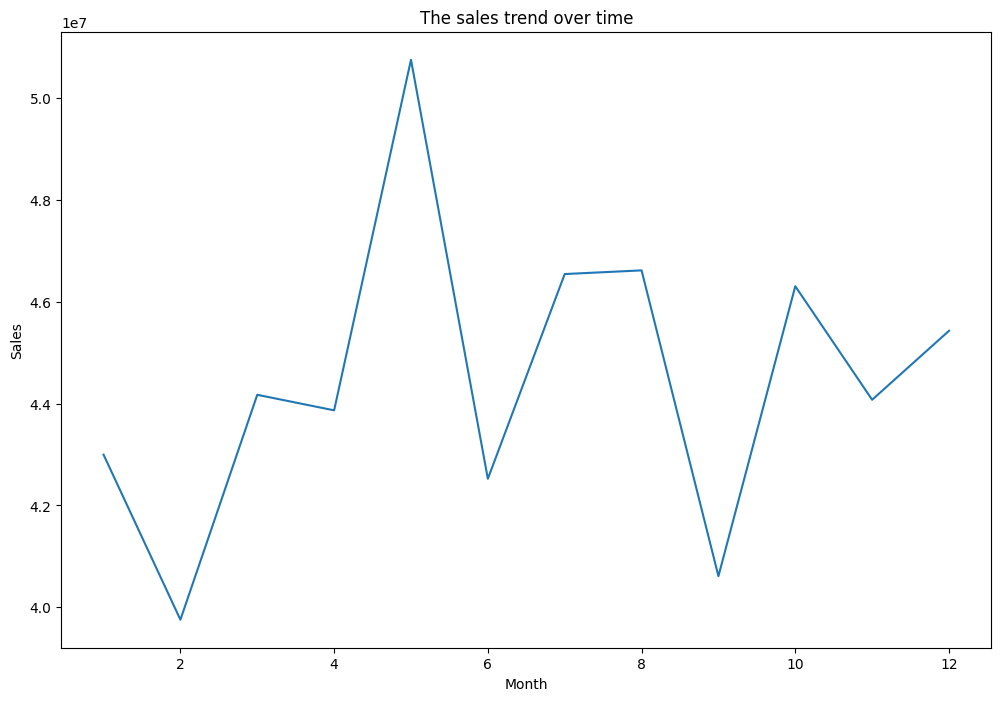

In [124]:
trend= df.groupby('Month')['Sales'].sum()
trend.plot(x='Month', y='Sales', kind='line', figsize=(12,8))
plt.title('The sales trend over time')
plt.xlabel('Month')
plt.ylabel('Sales')
plt.tight_layout
plt.show()

From the plot, we can see the time of the year where the sales are the highest . This can help the business make informed decisions to 
maximize profits and minimize loss. E.g High restocking in June and February may make the business incur more loss as we have low sales and perishable 
goods may expire. The business is likely to make high profits when the restock accordingly around the month of  January, March, May, July, August, October and December

# Checking sales trend of categories over time in different Regions

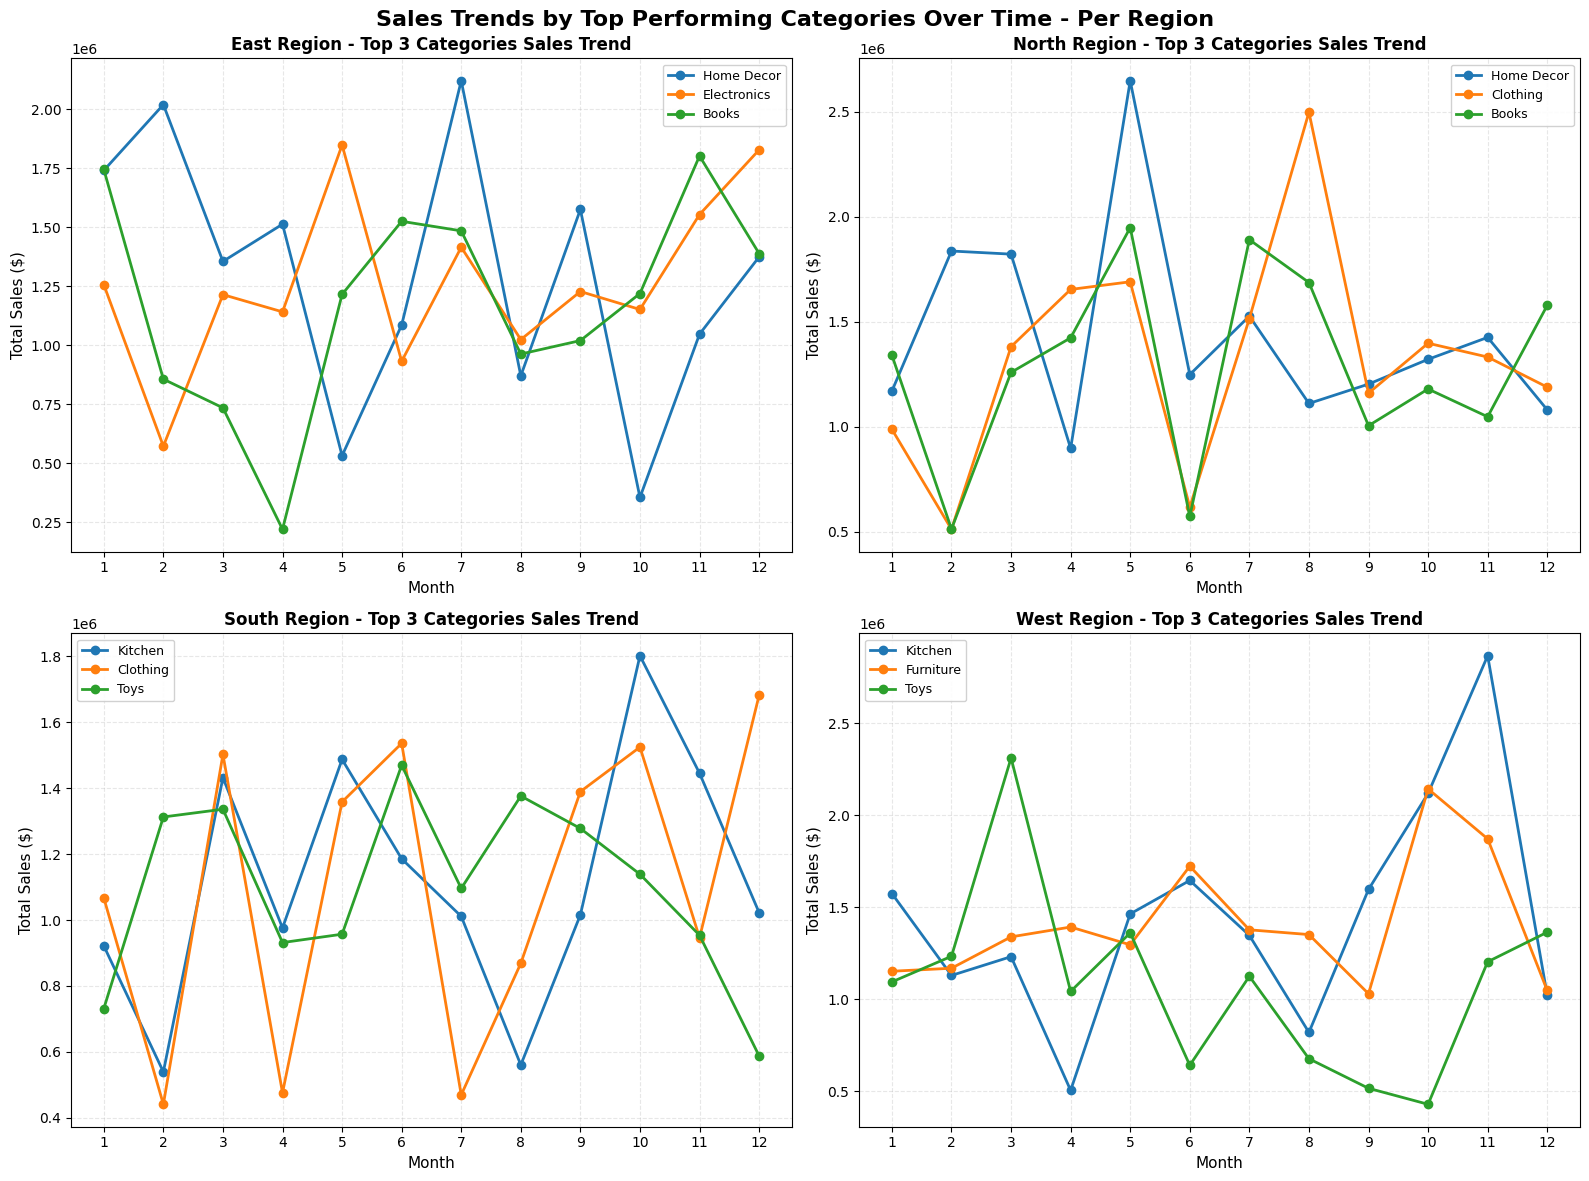

In [125]:
# Plot trend of sales per category in different times for each region
fig, axes = plt.subplots(2, 2, figsize=(16, 12))
fig.suptitle('Sales Trends by Top Performing Categories Over Time - Per Region', fontsize=16, fontweight='bold')

# Get unique regions
regions = sorted(df['Region'].unique())

# Flatten axes for easier iteration
axes_flat = axes.flatten()

# Create a plot for each region
for idx, region in enumerate(regions):
    ax = axes_flat[idx]
    
    # Filter data for this region
    region_data = df[df['Region'] == region]
    
    # Get top 3 performing categories by total sales in this region
    top_categories = region_data.groupby('Category')['Sales'].sum().nlargest(3).index.tolist()
    
    # Plot only top categories as separate lines
    for cat in top_categories:
        cat_data = region_data[region_data['Category'] == cat].groupby('Month')['Sales'].sum()
        ax.plot(cat_data.index, cat_data.values, marker='o', label=cat, linewidth=2, markersize=6)
    
    ax.set_title(f'{region} Region - Top 3 Categories Sales Trend', fontsize=12, fontweight='bold')
    ax.set_xlabel('Month', fontsize=11)
    ax.set_ylabel('Total Sales ($)', fontsize=11)
    ax.legend(loc='best', fontsize=9, framealpha=0.9)
    ax.grid(True, alpha=0.3, linestyle='--')
    ax.set_xticks(range(1, 13))

plt.tight_layout()
plt.show()

From the graph we displayed the trend of sales of the most selling categories on different regions throughout the year to identify
some of the categories that could be in peak demand in a specific month of the year. we realize that  in the east region, electronics sell
the highest during the month of may, home decor in July and Books in November. In the north region, Home Decor sell the highest during may, Clothing 
during August and Books during December.On the other hand in the South Region,kitchen category goods sell the most during October, Toys during August and Clothing
during December. Finally in the West region, Toys in March are the highest selling category, Furniture during june and Kitchen during November.
This helps the business make informed decision in restocking goods in different regions.

# Data Splitting and Preparations

Linear Regression model

In [126]:
#Regression model to predict sales 
# Prepare the data for modelling with One-Hot Encoding
x_encode = pd.get_dummies(df[['City', 'Region', 'Category', 'Sub-Category', 'Payment Mode']], drop_first=True)
# Combine encoded features with Discount, Quantity, and Unit Price
X = pd.concat([x_encode, df[['Discount', 'Unit Price', 'Quantity']]], axis=1)
y = df['Sales']

# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


We are building a model that forecasts the sales based on city, Region, Sub-Category, Payment Mode, Discount, Unit Price and Quantity.
we are splitting the data into training and splitting test. we are using 80% to train the model and 20% to test the model. the non numerical
features are encoded to categorical values.

# Modelling

In [127]:

# Create and fit the linear regression model
model = LinearRegression()
model.fit(X_train, y_train)

# Make Predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)
train_r2 = model.score(X_train, y_train)

print(f'Root Mean Squared Error: {rmse:.2f}')
print(f'R-squared (Test): {r2:.4f}')
print(f'R-squared (Train): {train_r2:.4f}')


Root Mean Squared Error: 30761.46
R-squared (Test): 0.8755
R-squared (Train): 0.8781


The model accounts for 87.81% change in sales. This model makes an error of approximately + or - 30761.46
Let us check the importance of each feature in our model 

In [128]:
# Feature importance grouped by main feature categories
# Get coefficients
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_,
    'Abs_Coefficient': abs(model.coef_)
})

# Extract base feature names for grouping
def get_base_feature(feature_name):
    if '_' in feature_name:
        return feature_name.split('_')[0]
    else:
        return feature_name

coefficients['Base_Feature'] = coefficients['Feature'].apply(get_base_feature)

# Group by base feature and sum the absolute coefficients
grouped_importance = coefficients.groupby('Base_Feature').agg({
    'Abs_Coefficient': 'sum',
    'Coefficient': 'sum'
}).reset_index()

# Rename columns for clarity
grouped_importance.columns = ['Feature_Group', 'Total_Abs_Importance', 'Total_Coefficient']
grouped_importance = grouped_importance.sort_values('Total_Abs_Importance', ascending=False)

print("\n=== FEATURE IMPORTANCE BY CATEGORY ===")
print("(Importance measured by sum of absolute coefficients)")
print(grouped_importance.to_string(index=False))




=== FEATURE IMPORTANCE BY CATEGORY ===
(Importance measured by sum of absolute coefficients)
Feature_Group  Total_Abs_Importance  Total_Coefficient
 Sub-Category         107649.266509      -16447.711186
     Quantity          35982.072385       35982.072385
         City          28773.454823        1067.013567
     Category          12714.511809        7602.733066
 Payment Mode           2314.679691       -2314.679691
       Region           1797.580710        1035.291717
     Discount           1133.695541       -1133.695541
   Unit Price              2.676230           2.676230


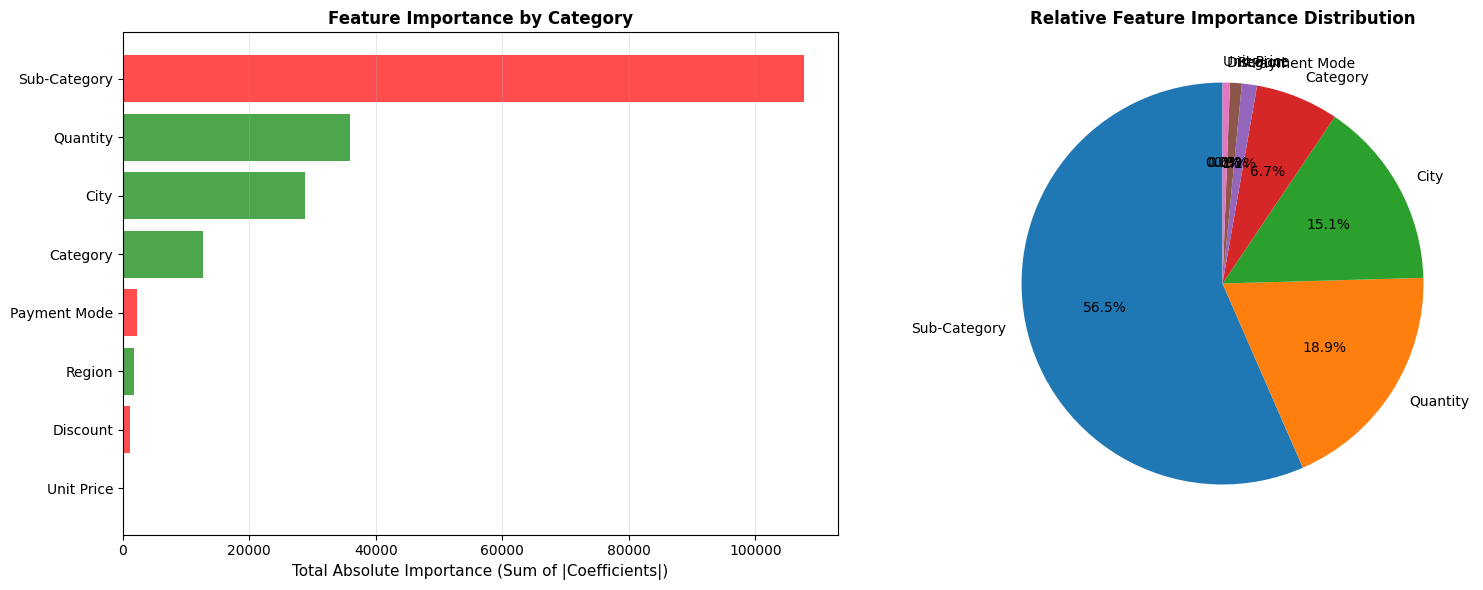


=== SUMMARY ===
Sub-Category: 107649.27 (56.5%)
Quantity: 35982.07 (18.9%)
City: 28773.45 (15.1%)
Category: 12714.51 (6.7%)
Payment Mode: 2314.68 (1.2%)
Region: 1797.58 (0.9%)
Discount: 1133.70 (0.6%)
Unit Price: 2.68 (0.0%)


In [129]:
# Visualize grouped feature importance
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Bar chart of absolute importance
ax1 = axes[0]
colors = ['green' if x > 0 else 'red' for x in grouped_importance['Total_Coefficient']]
ax1.barh(range(len(grouped_importance)), grouped_importance['Total_Abs_Importance'], color=colors, alpha=0.7)
ax1.set_yticks(range(len(grouped_importance)))
ax1.set_yticklabels(grouped_importance['Feature_Group'])
ax1.set_xlabel('Total Absolute Importance (Sum of |Coefficients|)', fontsize=11)
ax1.set_title('Feature Importance by Category', fontsize=12, fontweight='bold')
ax1.invert_yaxis()
ax1.grid(True, alpha=0.3, axis='x')

# Plot 2: Pie chart showing relative importance
ax2 = axes[1]
ax2.pie(grouped_importance['Total_Abs_Importance'], 
        labels=grouped_importance['Feature_Group'], 
        autopct='%1.1f%%',
        startangle=90)
ax2.set_title('Relative Feature Importance Distribution', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Print summary statistics
print("\n=== SUMMARY ===")
total_importance = grouped_importance['Total_Abs_Importance'].sum()
for idx, row in grouped_importance.iterrows():
    percentage = (row['Total_Abs_Importance'] / total_importance) * 100
    print(f"{row['Feature_Group']}: {row['Total_Abs_Importance']:.2f} ({percentage:.1f}%)")


In [130]:
# Try Random Forest for comparison

# Create and fit the Random Forest model
rf_model = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=15)
rf_model.fit(X_train, y_train)

# Make Predictions on the test set
y_pred_rf = rf_model.predict(X_test)

# Evaluate the model
mse_rf = mean_squared_error(y_test, y_pred_rf)
rmse_rf = mse_rf ** 0.5
r2_rf = r2_score(y_test, y_pred_rf)
train_r2_rf = rf_model.score(X_train, y_train)

print("\n=== RANDOM FOREST MODEL ===")
print(f'Mean Squared Error: {mse_rf:.2f}')
print(f'Root Mean Squared Error: {rmse_rf:.2f}')
print(f'R-squared (Test): {r2_rf:.4f}')
print(f'R-squared (Train): {train_r2_rf:.4f}')


=== RANDOM FOREST MODEL ===
Mean Squared Error: 4446373.36
Root Mean Squared Error: 2108.64
R-squared (Test): 0.9994
R-squared (Train): 0.9999


From the above models we can see that Random Forest gives us a higher r2_score. That shows that random forest model accounts for more variability
in sales. Random forest predicts sales better. 

Cross Validation

In [131]:
# Linear Regression model Cross validation
lr = LinearRegression()

scores_lr = cross_val_score(lr, X, y, cv=5, scoring='r2')

print("LR scores:", scores_lr)
print("LR mean:", scores_lr.mean())

LR scores: [0.87440919 0.88180752 0.87078672 0.8648173  0.87871558]
LR mean: 0.8741072644482074


In [133]:
# Random Forest model Cross validation
rf = RandomForestRegressor(n_estimators=100, random_state=42)
scores_rf = cross_val_score(rf, X, y, cv=5, scoring='r2')

print("RF scores:", scores_rf)
print("RF mean:", scores_rf.mean())

RF scores: [0.99936828 0.9993606  0.99948242 0.99937453 0.99942368]
RF mean: 0.9994019016177212


 LINEAR REGRESSION MODEL DETAILS 
Model Intercept: -96393.2231

Model Coefficients:
                  Feature   Coefficient
86               Quantity  35982.072385
66   Sub-Category_Shampoo  -7558.536818
67     Sub-Category_Shoes  -5238.519281
71     Sub-Category_Sugar  -5185.636468
23      Category_Clothing   4994.509614
..                    ...           ...
29        Category_Sports     80.619407
30          Category_Toys    -70.205320
17             City_Surat     54.763224
79  Sub-Category_Yoga Mat    -48.787163
85             Unit Price      2.676230

[87 rows x 2 columns]

 PREDICTION ON NEW DATA 
Predicted Sales for new sample: $87351.51

 RESIDUAL ANALYSIS 


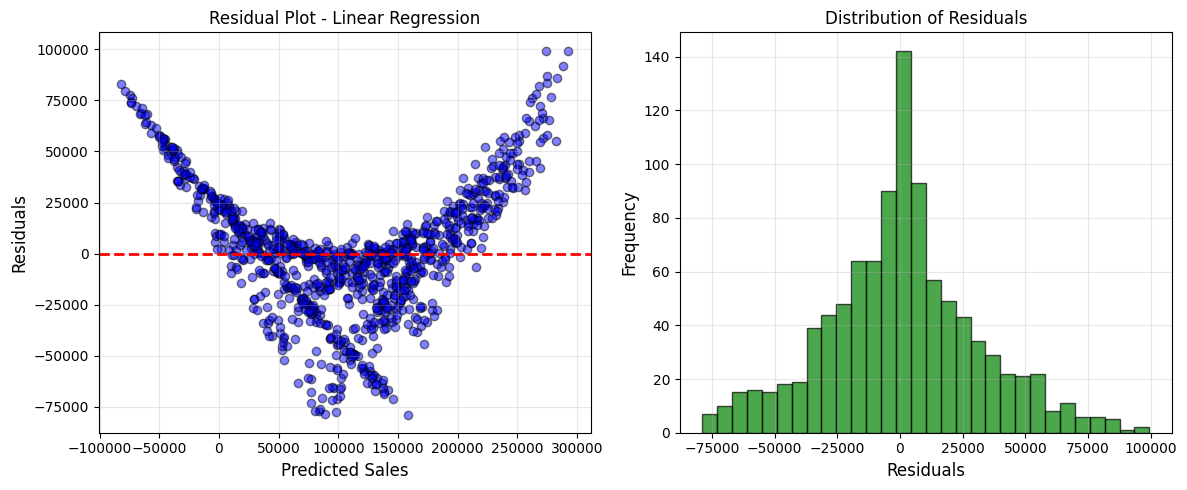

Mean of Residuals: 537.9010
Std Dev of Residuals: 30772.1500
Min Residual: -78844.1697
Max Residual: 99459.5186


In [132]:
# Model Intercept and Coefficients
print(" LINEAR REGRESSION MODEL DETAILS ")
print(f"Model Intercept: {model.intercept_:.4f}")
print("\nModel Coefficients:")
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': model.coef_
}).sort_values('Coefficient', key=abs, ascending=False)
print(coefficients)

# Predict on new data
print("\n PREDICTION ON NEW DATA ")
# Create a sample prediction
new_sample = pd.DataFrame({
    'City_Chicago': [0], 'City_Houston': [0], 'City_Los Angeles': [1], 'City_Miami': [0], 'City_New York': [0],
    'Region_East': [0], 'Region_Midwest': [0], 'Region_South': [0], 'Region_West': [1],
    'Category_Clothing': [0], 'Category_Electronics': [0], 'Category_Furniture': [0], 'Category_Groceries': [0],
    'Category_Home Decor': [1], 'Category_Kitchen': [0], 'Category_Sports': [0], 'Category_Toys': [0],
    'Sub-Category_Accessories': [0], 'Sub-Category_Appliances': [0], 'Sub-Category_Beauty': [0],
    'Sub-Category_Books': [0], 'Sub-Category_Clothing': [1], 'Sub-Category_Furniture': [0],
    'Sub-Category_Gaming': [0], 'Sub-Category_Home Decor': [0], 'Sub-Category_Kitchen': [0],
    'Sub-Category_Phones': [0], 'Sub-Category_Shoes': [0], 'Sub-Category_Sports': [0], 'Sub-Category_Toys': [0],
    'Payment Mode_Card': [0], 'Payment Mode_Cash': [0], 'Payment Mode_Cheque': [0], 'Payment Mode_COD': [1], 'Payment Mode_Online': [0],
    'Discount': [0.15], 'Quantity': [5], 'Unit Price': [50]
})

# Ensure columns match X_train
new_sample = new_sample.reindex(columns=X_train.columns, fill_value=0)
predicted_sales = model.predict(new_sample)
print(f"Predicted Sales for new sample: ${predicted_sales[0]:.2f}")

# Residual Plot
print("\n RESIDUAL ANALYSIS ")
residuals = y_test - y_pred

plt.figure(figsize=(12, 5))

# Plot 1: Residuals vs Predicted Values
plt.subplot(1, 2, 1)
plt.scatter(y_pred, residuals, alpha=0.5, color='blue', edgecolors='black')
plt.axhline(y=0, color='r', linestyle='--', linewidth=2)
plt.xlabel('Predicted Sales', fontsize=12)
plt.ylabel('Residuals', fontsize=12)
plt.title('Residual Plot - Linear Regression', fontsize=12)
plt.grid(True, alpha=0.3)

# Plot 2: Distribution of Residuals
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, color='green', edgecolor='black', alpha=0.7)
plt.xlabel('Residuals', fontsize=12)
plt.ylabel('Frequency', fontsize=12)
plt.title('Distribution of Residuals', fontsize=12)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Residual statistics
print(f"Mean of Residuals: {residuals.mean():.4f}")
print(f"Std Dev of Residuals: {residuals.std():.4f}")
print(f"Min Residual: {residuals.min():.4f}")
print(f"Max Residual: {residuals.max():.4f}")
